# 01 - Exploratory Data Analysis

Dataset: Kaggle "Brain Tumor MRI Dataset" v2 (4 classes: glioma, meningioma, pituitary, notumor).

## 1. Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import imagehash
from tqdm.auto import tqdm

c:\Users\briek\Desktop\AI_Portfolio\brain-tumor-mri-classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Paths

In [ ]:
DATA_DIR = Path("..") / "data"
TRAIN_DIR = DATA_DIR / "Training"
TEST_DIR = DATA_DIR / "Testing"

## 3. Class distribution

### 3.1 Image table

One row per image. Split and label come from the folder names: `data/<split>/<label>/<file>.jpg`.

In [3]:
paths = sorted(DATA_DIR.glob("*/*/*.jpg"))

df = pd.DataFrame({"path": paths})
df["split"] = [p.parent.parent.name for p in paths]
df["label"] = [p.parent.name for p in paths]
df.head()

,path,split,label
0,..\data\Testing\glioma\Te-gl_1.jpg,Testing,glioma
1,..\data\Testing\glioma\Te-gl_10.jpg,Testing,glioma
2,..\data\Testing\glioma\Te-gl_100.jpg,Testing,glioma
3,..\data\Testing\glioma\Te-gl_101.jpg,Testing,glioma
4,..\data\Testing\glioma\Te-gl_102.jpg,Testing,glioma


### 3.2 Counts per class and split

In [ ]:
counts = pd.crosstab(df["label"], df["split"], margins=True, margins_name="total")
counts

split,Testing,Training,total
label,,,
glioma,400,1400,1800
meningioma,400,1400,1800
notumor,400,1400,1800
pituitary,400,1400,1800
total,1600,5600,7200


### 3.3 Plot

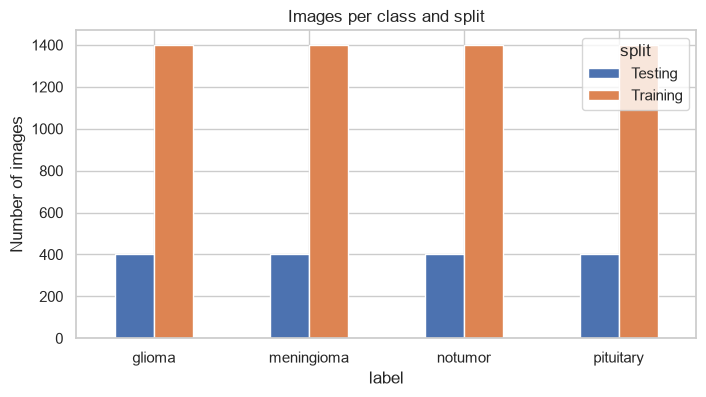

In [5]:
counts.drop(index="total", columns="total").plot(kind="bar", rot=0, figsize=(8, 4), title="Images per class and split")
plt.ylabel("Number of images")
plt.show()

### 3.4 Conclusions

- 7,200 images: 1,400 train and 400 test per class, so the classes are perfectly balanced.
- No validation set yet: it will be split off from the training data in `02_preprocessing`.

## 4. Image size and color mode

### 4.1 Read size and mode


In [6]:
df["width"] = [Image.open(p).width for p in paths]
df["height"] = [Image.open(p).height for p in paths]
df["mode"] = [Image.open(p).mode for p in paths]
df["size"] = df["width"].astype(str) + "x" + df["height"].astype(str)
df.head()

,path,split,label,width,height,mode,size
0,..\data\Testing\glioma\Te-gl_1.jpg,Testing,glioma,354,442,RGB,354x442
1,..\data\Testing\glioma\Te-gl_10.jpg,Testing,glioma,512,512,L,512x512
2,..\data\Testing\glioma\Te-gl_100.jpg,Testing,glioma,512,512,L,512x512
3,..\data\Testing\glioma\Te-gl_101.jpg,Testing,glioma,512,512,L,512x512
4,..\data\Testing\glioma\Te-gl_102.jpg,Testing,glioma,339,406,RGB,339x406


### 4.2 Color mode per class

`L` = grayscale, `RGB` = color, `P` = palette, `RGBA` = color with transparency.

In [16]:
pd.crosstab(df["label"], df["mode"])

mode,L,P,RGB,RGBA
label,,,,
glioma,1399,0,401,0
meningioma,709,0,1091,0
notumor,29,1,1767,3
pituitary,930,0,870,0


### 4.3 Size per class

In [17]:
df["square"] = df["width"] == df["height"]

df.groupby("label").agg(
    median_width=("width", "median"),
    median_height=("height", "median"),
    n_sizes=("size", "nunique"),
    square_share=("square", "mean"),
)

,median_width,median_height,n_sizes,square_share
label,,,,
glioma,512.0,512.0,62,0.963889
meningioma,512.0,512.0,126,0.882222
notumor,228.0,243.0,250,0.321667
pituitary,512.0,512.0,27,0.980556


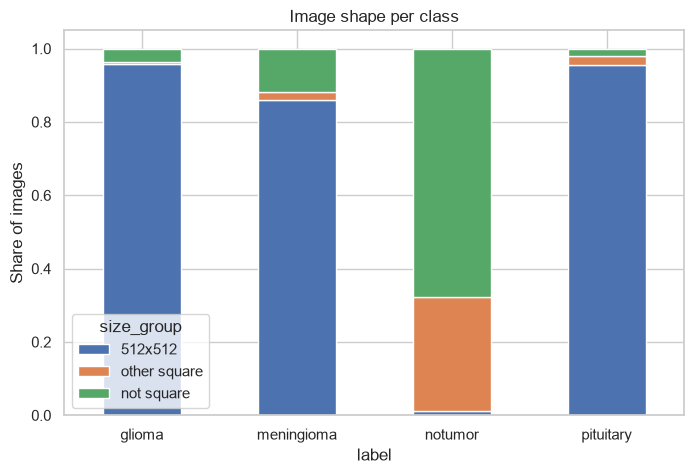

In [18]:
df["size_group"] = np.where(df["size"] == "512x512", "512x512", np.where(df["square"], "other square", "not square"))

size_groups = pd.crosstab(df["label"], df["size_group"], normalize="index")[["512x512", "other square", "not square"]]
size_groups.plot(kind="bar", stacked=True, rot=0, figsize=(8, 5), title="Image shape per class")
plt.ylabel("Share of images")
plt.show()

### 4.4 Conclusions

- A lot of the glioma, meningioma and pituitary images are exactly 512x512, compared to only 1% of the notumor images.
- Notumor is much smaller (median ~230 px), has 250 different sizes and about 2/3 are not square.
- Notumor is almost entirely RGB, the other classes are a mix of grayscale and RGB.
- This is a strong sign of source bias: a model could learn "notumor" from size or format instead of the brain.
- Preprocessing must resize all images to one size and convert them to grayscale.